In [6]:
# %% [修改 Cell 1 中的导入部分]
import sys
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 重点关注这里：添加了 QSlider
from PySide6.QtWidgets import (QApplication, QMainWindow, QWidget, QVBoxLayout, 
                             QHBoxLayout, QFormLayout, QLineEdit, QPushButton, 
                             QLabel, QComboBox, QGroupBox, QScrollArea, QMessageBox,
                             QSlider, QCheckBox) 

from PySide6.QtCore import Qt
import xgboost
import lightgbm

# ================== 1. 全局配置 ==================
BASE_PATH = r"C:\Users\GIGABYTE\Desktop\Test\Analysis\新（可用）\CSV"
TARGET_KEYS = ["EUI", "sDA", "sGA", "UDI", "SVF"]
TARGET_DISPLAY = {
    "EUI": "EUI (kWh/m²)",
    "sDA": "sDA<sub>450/50%</sub> (%)",
    "sGA": "sGA<sub>0.35, 5%</sub> (%)",
    "UDI": "UDI<sub>100-2000lx</sub> (%)",
    "SVF": "SVF (%)"
}

FEATURE_ORDER = [
    'WWR_s_exp', 'WWR_s', 'H_s', 'W_s', 'SH_s', 'd_A_s', 'd_B_s',
    'WWR_c', 'H_c', 'W_c', 'SH_c', 'd_A_c', 'd_B_c',
    'F_BL', 'F_BR', 'F_TR', 'F_TL',
    'alpha_oh', 'L_oh', 'd_mv',
    'N_v', 'W_v', 'L_v', 'M_TL', 'M_TR'
]

# 预测模型依然只识别物理参数，不识别 WWR_s_exp
SHADE_FEATURE_MAP = {
    "基准 (Base)": FEATURE_ORDER[1:13],
    "框式 (Frame)": FEATURE_ORDER[1:13] + FEATURE_ORDER[13:17],
    "悬挑 (Overhang)": FEATURE_ORDER[1:13] + FEATURE_ORDER[17:20],
    "垂直 (Vertical)": FEATURE_ORDER[1:13] + FEATURE_ORDER[20:25],
    "组合 (O+V)": FEATURE_ORDER[1:13] + FEATURE_ORDER[17:25]
}

ORI_LIST = ["南向 (South 0°)", "北向 (North 0°)"]
SHADE_LIST = ["基准 (Base)", "悬挑 (Overhang)", "垂直 (Vertical)", "组合 (O+V)", "框式 (Frame)"]

# 论文数据预设 (WWR_s 在这里作为 WWR_s_exp 填入)
PRESET_DATA = {
    (ORI_LIST[0], SHADE_LIST[0]): {'WWR_s':30,'H_s':2,'SH_s':0.9,'WWR_c':15,'H_c':0.9,'W_c':4.5,'SH_c':0.8},
    (ORI_LIST[0], SHADE_LIST[1]): {'WWR_s':30,'H_s':1.2,'SH_s':1,'WWR_c':15,'H_c':1.2,'W_c':3.4,'SH_c':0.8,'alpha_oh':20,'L_oh':1.9,'d_mv':0},
    (ORI_LIST[0], SHADE_LIST[2]): {'WWR_s_exp':31,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2,'N_v':2,'W_v':1,'L_v':0.1,'M_TL':0,'M_TR':0.2},
    (ORI_LIST[0], SHADE_LIST[3]): {'WWR_s_exp':31,'H_s':1.4,'SH_s':0.8,'WWR_c':20,'H_c':0.9,'W_c':6,'SH_c':0.8,'alpha_oh':50,'L_oh':2,'d_mv':0,'N_v':7,'W_v':0.3,'L_v':0.2,'M_TL':0.15,'M_TR':0},
    (ORI_LIST[0], SHADE_LIST[4]): {'WWR_s':30,'H_s':2,'SH_s':1,'WWR_c':15,'H_c':1,'W_c':4,'SH_c':1,'F_BL':0.7,'F_BR':1.4,'F_TR':1.1,'F_TL':0.9},
    (ORI_LIST[1], SHADE_LIST[0]): {'WWR_s':40,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2},
    (ORI_LIST[1], SHADE_LIST[1]): {'WWR_s':35,'H_s':2.2,'SH_s':0.8,'WWR_c':15,'H_c':0.9,'W_c':4.5,'SH_c':0.8,'alpha_oh':80,'L_oh':0.4,'d_mv':0.8},
    (ORI_LIST[1], SHADE_LIST[2]): {'WWR_s_exp':40,'H_s':1.9,'SH_s':1,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2,'N_v':8,'W_v':0.3,'L_v':0.1,'M_TL':0.1,'M_TR':0},
    (ORI_LIST[1], SHADE_LIST[3]): {'WWR_s_exp':40,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.6,'W_c':4.5,'SH_c':2,'alpha_oh':-80,'L_oh':1.5,'d_mv':0.5,'N_v':5,'W_v':0.02,'L_v':0.1,'M_TL':0,'M_TR':0},
    (ORI_LIST[1], SHADE_LIST[4]): {'WWR_s':40,'H_s':2.6,'SH_s':0.4,'WWR_c':10,'H_c':0.8,'W_c':3.4,'SH_c':2,'F_BL':0.1,'F_BR':0.4,'F_TR':0.1,'F_TL':0.1}
}

In [7]:
# %% [Cell 2: 几何引擎 - 增加遮阳板长度物理约束]

def geometry_engine(ui, mode):
    """
    处理所有几何联动逻辑
    ui: 包含原始输入的字典
    mode: 遮阳形式字符串
    """
    wa = 27.0  # 墙面积
    wl = 9.0   # 墙长
    
    # 1. 常规参数提取 (带安全转换)
    def safe_float(key, default=0.0):
        val = ui.get(key, default)
        try: return float(val) if val is not None else default
        except: return default

    hs = safe_float('H_s', 2.0)
    hc = safe_float('H_c', 1.0)
    wv = safe_float('W_v', 0.1)
    
    # --- A. 遮阳板物理长度(L)缩进逻辑 (您提供的逻辑) ---
    # 假设 FEATURE_ORDER 中的 Key 如下，请根据实际名称修改
    a = safe_float('Distance_d', 0.1)
    b = safe_float('Distance_st', 0.1)
    L_orig = safe_float('Length', 1.0) # 用户输入的原始长度
    d_orig = safe_float('Distance_c', 0.5)
    angle = safe_float('Overhang_angle', 0.0)
    
    L_final = L_orig
    d_final = d_orig

    if angle < 0:
        # 只有角度小于 0 时，才检查物理碰撞
        while d_final > (a + b):
            L_final = round(L_final - 0.1, 2)
            d_final = round(d_final - 0.1, 2)
            if L_final <= 0:
                L_final = 0
                break
    else:
        # 角度 >= 0，保持原始长度
        L_final = L_orig

    # --- B. 走廊窗 WWR_c 逻辑 (之前的约束) ---
    wwr_c_in = safe_float('WWR_c', 15)
    max_area_c = 6.2 * hc
    max_wwr_c = (max_area_c / wa) * 100.0
    real_wwr_c = min(wwr_c_input, max_wwr_c) if 'wwr_c_input' in locals() else min(wwr_c_in, max_wwr_c)
    wc_actual = min((real_wwr_c / 100.0 * wa) / max(0.1, hc), 6.2)

    # --- C. 南向采光窗 WWR_s 逻辑 (之前的约束) ---
    if mode in ["垂直 (Vertical)", "组合 (O+V)"]:
        nv = max(2, int(safe_float('N_v', 2)))
        wwr_s_exp = safe_float('WWR_s_exp', 30)
        max_s_w = 7.8
        temp_w = min((wwr_s_exp / 100.0 * wa) / hs, max_s_w)
        ws_pane = round(max(0.1, temp_w - (nv - 1) * wv) / (nv - 1), 1)
        actual_wwr_s = round((ws_pane * (nv - 1) * hs / wa) * 100.0)
    else:
        nv = 0
        wwr_s_in = safe_float('WWR_s', 30)
        actual_w = min((wwr_s_in / 100.0 * wa) / hs, 7.8)
        ws_pane = round(actual_w, 1)
        actual_wwr_s = round((ws_pane * hs / wa) * 100.0)

    # --- D. 封送结果 ---
    res = {k: safe_float(k) for k in FEATURE_ORDER}
    res.update({
        'WWR_s': int(actual_wwr_s),
        'WWR_c': int(real_wwr_c),
        'W_s': ws_pane,
        'W_c': round(wc_actual, 2),
        'N_v': nv,
        'Length': L_final,    # 返回修正后的遮阳板长度
        'Distance_c': d_final # 返回同步修正后的距离
    })
    return res

## Cell 3a: 3D 物理绘图引擎 (Visualization Engine)


In [8]:
# %%
def draw_classroom_3d(ax, data, sha_mode):
    """
    专门负责 3D 几何绘制的独立函数
    补充：走廊地坪、走廊吊顶(3.0-3.8m)、走廊侧窗
    """
    ax.clear()
    L, D, H_total = 9.0, 9.0, 3.8 

    # --- 1. 视觉纠偏：正交投影 + 1:1 比例锁定 ---
    ax.set_proj_type('ortho') 
    span = 14                 
    ax.set_xlim(-4, 10)       
    ax.set_ylim(-2.5, 11.5)   
    ax.set_zlim(0, 5)
    ax.set_box_aspect((span, span, H_total)) 
    ax.set_axis_off()

    # --- 2. 绘制主体框架 (室内 3.8m 无吊顶) ---
    for z in [0, H_total]:
        ax.plot3D([0,9,9,0,0],[0,0,9,9,0],[z,z,z,z,z], 'black', lw=1.5)
    for x, y in [(0,0),(9,0),(9,9),(0,9)]:
        ax.plot3D([x,x],[y,y],[0,H_total], 'k', lw=1, alpha=0.4)

    # --- 3. 走廊侧构造 (X=0 墙面及 X<0 空间) ---
    # A. 走廊地坪 (X: -3 to 0)
    corr_floor = [[(-3, 0, 0), (0, 0, 0), (0, 9, 0), (-3, 9, 0)]]
    ax.add_collection3d(Poly3DCollection(corr_floor, facecolors='gray', alpha=0.1))

    # B. 走廊吊顶/静压箱 (3.0m - 3.8m)
    # 绘制底面(3.0m)和顶面(3.8m)
    c_plenum = [
        [(-3, 0, 3.0), (0, 0, 3.0), (0, 9, 3.0), (-3, 9, 3.0)], # 吊顶底
        [(-3, 0, 3.8), (0, 0, 3.8), (0, 9, 3.8), (-3, 9, 3.8)]  # 走廊顶
    ]
    ax.add_collection3d(Poly3DCollection(c_plenum, facecolors='gray', alpha=0.3))

# %% [修改 Cell 3a：走廊窗动态绘图部分]
    # C. 走廊侧窗户 (Window_C) 绘制逻辑
    # 从 data 字典中获取刚才 Cell 2 算出来的动态 W_c
    wc_draw = data.get('W_c', 4.0) 
    hc_draw = data.get('H_c', 1.0)
    shc_draw = data.get('SH_c', 1.0)
    
    # 居中算法：(总长 9.0 - 窗宽) / 2
    # 当 wc_draw = 6.2 时，yc_start 刚好是 1.4，完美避开门
    yc_start = (9.0 - wc_draw) / 2
    
    win_c_verts = [[(0, yc_start, shc_draw), 
                    (0, yc_start + wc_draw, shc_draw), 
                    (0, yc_start + wc_draw, shc_draw + hc_draw), 
                    (0, yc_start, shc_draw + hc_draw)]]
    
    ax.add_collection3d(Poly3DCollection(win_c_verts, facecolors='lightgreen', 
                                         edgecolors='g', alpha=0.5, lw=1))

    # D. 走廊侧双门 (已有的逻辑)
    for yd in [0.2, 9-0.2-1.2]:
        dr = [[(0, yd, 0), (0, yd+1.2, 0), (0, yd+1.2, 2.2), (0, yd, 2.2)]]
        ax.add_collection3d(Poly3DCollection(dr, facecolors='saddlebrown', edgecolors='k', alpha=0.8))

# --- 4. 南侧窗户分格绘制 (X=9) 修正版 ---
    is_v = "垂直" in sha_mode or "组合" in sha_mode
    nv = int(data.get('N_v', 0))
    wv = data.get('W_v', 0.1)
    ws_pane = data.get('W_s', 4.0)
    hs = data.get('H_s', 2.0)
    shs = data.get('SH_s', 0.9)

    if is_v and nv >= 2:
        num_p = nv - 1
        total_opening_w = (num_p * ws_pane) + (nv - 1) * wv
    else:
        num_p = 1
        total_opening_w = ws_pane
    
    # 【核心修改：黑板避让逻辑】
    # 1. 尝试居中对齐
    ys_ideal = (D - total_opening_w) / 2
    # 2. 强制左侧留白至少 1.0m (黑板侧)
    # 3. 同时确保右侧不超出墙体 (假设右侧留 0.1m 结构缝隙，即最大到 8.9)
    ys_start = max(1.0, ys_ideal)
    
    # 检查如果窗户太宽导致右侧撞墙，强制往左挤（但不能挤进黑板 1m 区）
    if ys_start + total_opening_w > 8.9:
        ys_start = max(1.0, 8.9 - total_opening_w)

    for i in range(num_p):
        if is_v and nv >= 2:
            # 这里的起始位置也基于新的 ys_start
            curr_y = ys_start + wv/2 + i * (ws_pane + wv)
        else:
            curr_y = ys_start
            
        pane = [[(9, curr_y, shs), (9, curr_y+ws_pane, shs), (9, curr_y+ws_pane, shs+hs), (9, curr_y, shs+hs)]]
        ax.add_collection3d(Poly3DCollection(pane, facecolors='skyblue', edgecolors='b', alpha=0.5))

    # --- 5. 垂直遮阳绘制 ---
    if is_v and nv > 0:
        lv, mtl, mtr = data.get('L_v', 0), data.get('M_TL', 0), data.get('M_TR', 0)
        for i in range(nv):
            by = ys_start + i * (ws_pane + wv)
            p1, p2 = (9, by - wv/2, 0), (9, by + wv/2, 0)
            p3, p4 = (9, by + wv/2, 3.8), (9, by - wv/2, 3.8)
            p5 = (9 + lv, by - wv/2 + mtl, 0)
            p6 = (9 + lv, by + wv/2 - mtr, 0)
            p7 = (9 + lv, by + wv/2 - mtr, 3.8)
            p8 = (9 + lv, by - wv/2 + mtl, 3.8)
            ax.add_collection3d(Poly3DCollection([[p1,p2,p3,p4],[p5,p6,p7,p8],[p1,p5,p8,p4],[p2,p6,p7,p3],[p1,p2,p6,p5],[p4,p3,p7,p8]], facecolors='teal', alpha=0.8, edgecolors='k', lw=0.3))

    # --- 6. 悬挑遮阳 (通长 9m) ---
    if ("悬挑" in sha_mode or "组合" in sha_mode) and data.get('L_oh', 0) > 0:
        alpha, loh, dmv = np.radians(data.get('alpha_oh', 0)), data['L_oh'], data.get('d_mv', 0)
        zt = 3.8 - dmv
        z_end = zt - loh * np.sin(alpha)
        x_ext = 9 + loh * np.cos(alpha)
        oh_verts = [[(9, 0, zt), (x_ext, 0, z_end), (x_ext, 9, z_end), (9, 9, zt)]]
        ax.add_collection3d(Poly3DCollection(oh_verts, facecolors='indianred', alpha=0.8, edgecolors='darkred', lw=0.5))

    # 8. 框式遮阳绘制
    if "框式" in sha_mode:
        fbl, fbr, ftr, ftl = data.get('F_BL',0), data.get('F_BR',0), data.get('F_TR',0), data.get('F_TL',0)
        p_bl, p_br = (9, ys_start, shs), (9, ys_start+total_opening_w, shs)
        p_tr, p_tl = (9, ys_start+total_opening_w, shs+hs), (9, ys_start, shs+hs)
        e_bl, e_br = (9+fbl, ys_start, shs), (9+fbr, ys_start+total_opening_w, shs)
        e_tr, e_tl = (9+ftr, ys_start+total_opening_w, shs+hs), (9+ftl, ys_start, shs+hs)
        ax.add_collection3d(Poly3DCollection([[p_bl, p_br, e_br, e_bl], [p_br, p_tr, e_tr, e_br], [p_tr, p_tl, e_tl, e_tr], [p_tl, p_bl, e_bl, e_tl]], facecolors='orange', alpha=0.7, edgecolors='darkorange'))

    # --- 9. 最终文字标注 ---
    ax.text(9, 4.5, 4.1, f"Actual WWR: {data['WWR_s']}%", color='darkred', fontweight='bold', ha='center')
    ax.view_init(elev=25, azim=45)

## Cell 3b: GUI 控制中心 (Application logic)

In [ ]:
# %%
class ClassroomPredictorApp(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("青少年健康教室性能智能预测系统 - 建筑同步版")
        self.resize(1500, 950)
        
        # 1. 核心数据结构初始化
        self.model_map = {}
        self.model_cache = {}
        self.inputs = {}
        self.rows = {} 
        
        # 2. 按顺序启动
        self.scan_folders()
        self.init_ui()
        # 3. UI 建立后再执行第一次预设加载
        self.apply_presets()

    def scan_folders(self):
        """扫描模型文件夹逻辑"""
        if not os.path.exists(BASE_PATH): return
        folders = [d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))]
        for f in folders:
            ori = ORI_LIST[0] if "South0°" in f else (ORI_LIST[1] if "North0°" in f else None)
            if not ori: continue
            sha = SHADE_LIST[0]
            if "Overhang+Vertical" in f: sha = SHADE_LIST[3]
            elif "Overhang" in f: sha = SHADE_LIST[1]
            elif "Vertical" in f: sha = SHADE_LIST[2]
            elif "Frame" in f: sha = SHADE_LIST[4]
            self.model_map[(ori, sha)] = os.path.join(BASE_PATH, f)

    def init_ui(self):
        # 1. 主窗口容器布局
        main_widget = QWidget()
        self.setCentralWidget(main_widget)
        main_layout = QHBoxLayout(main_widget)
        
        # --- 左侧：滚动控制面板 ---
        scroll = QScrollArea()
        scroll.setFixedWidth(400)
        scroll.setWidgetResizable(True)
        left_container = QWidget()
        vbox = QVBoxLayout(left_container)
        
        # 2. 策略选择组
        grp_sel = QGroupBox("1. 策略选择")
        f_sel = QFormLayout(grp_sel)
        self.cb_ori = QComboBox()
        self.cb_sha = QComboBox()
        self.cb_ori.addItems(ORI_LIST)
        self.cb_sha.addItems(SHADE_LIST)
        self.cb_ori.currentTextChanged.connect(self.apply_presets)
        self.cb_sha.currentTextChanged.connect(self.apply_presets)
        f_sel.addRow("朝向:", self.cb_ori)
        f_sel.addRow("形式:", self.cb_sha)
        vbox.addWidget(grp_sel)

        # 3. 设计变量组
        grp_param = QGroupBox("2. 设计变量")
        self.param_form = QFormLayout(grp_param)
        
        for f in FEATURE_ORDER:
            lbl = QLabel(f"{f}:")
            row_widget = QWidget(grp_param)
            row_layout = QHBoxLayout(row_widget)
            row_layout.setContentsMargins(0, 0, 0, 0)
            
            # 滑块范围逻辑
            if f in ['WWR_s_exp', 'WWR_s', 'WWR_c']:
                min_v, max_v = (30, 70) if f != 'WWR_c' else (10, 40)
                slider = QSlider(Qt.Horizontal, row_widget)
                slider.setRange(min_v, max_v)
                slider.setSingleStep(5)
                slider.setTickPosition(QSlider.TicksBelow)
                slider.setTickInterval(5)
                
                val_lbl = QLabel(f"{slider.value()}%", row_widget)
                val_lbl.setFixedWidth(40)
                val_lbl.setStyleSheet("color: #2980b9; font-weight: bold;")
                
                def make_snap(s=slider, l=val_lbl):
                    def snap(v):
                        snapped = round(v / 5) * 5
                        s.blockSignals(True)
                        s.setValue(snapped)
                        s.blockSignals(False)
                        l.setText(f"{snapped}%")
                    return snap
                
                slider.valueChanged.connect(make_snap())
                row_layout.addWidget(slider)
                row_layout.addWidget(val_lbl)
                self.inputs[f] = slider
                self.rows[f] = (lbl, row_widget, val_lbl)
            else:
                edit = QLineEdit("0", row_widget)
                row_layout.addWidget(edit)
                self.inputs[f] = edit
                self.rows[f] = (lbl, row_widget, None)
            
            self.param_form.addRow(lbl, row_widget)
        
        vbox.addWidget(grp_param)
        grp_display = QGroupBox("3. 环境显示")
        display_layout = QVBoxLayout()
        self.chk_upper = QCheckBox("显示纵向叠加层 (楼上)")
        self.chk_side = QCheckBox("显示横向相邻间 (并排)")
        display_layout.addWidget(self.chk_upper)
        display_layout.addWidget(self.chk_side)
        grp_display.setLayout(display_layout)
        vbox.addWidget(grp_display)

        # 4. 预测按钮
        self.btn_run = QPushButton("⚡ 执行 Stacking 集成预测")
        self.btn_run.setFixedHeight(50)
        self.btn_run.setStyleSheet("background-color: #2c3e50; color: white; font-weight: bold;")
        self.btn_run.clicked.connect(self.do_prediction)
        vbox.addWidget(self.btn_run)
        vbox.addStretch()

        scroll.setWidget(left_container)
        main_layout.addWidget(scroll)

        # --- 右侧：预测结果看板与 3D 绘图 ---
        right_box = QVBoxLayout()
        res_grp = QGroupBox("预测看板")
        res_grid = QHBoxLayout()
        self.res_labels = {}
        for key in TARGET_KEYS:
            v_unit = QVBoxLayout()
            title = QLabel(TARGET_DISPLAY[key])
            title.setAlignment(Qt.AlignCenter)
            lbl_val = QLabel("--")
            lbl_val.setAlignment(Qt.AlignCenter)
            lbl_val.setStyleSheet("font-size: 20px; font-weight: bold; color: #d35400;")
            self.res_labels[key] = lbl_val
            v_unit.addWidget(title)
            v_unit.addWidget(lbl_val)
            res_grid.addLayout(v_unit)
        res_grp.setLayout(res_grid)
        right_box.addWidget(res_grp)

        self.fig = plt.figure(figsize=(9, 9))
        self.ax = self.fig.add_subplot(111, projection='3d')
        self.canvas = FigureCanvas(self.fig)
        right_box.addWidget(self.canvas)
        main_layout.addLayout(right_box)

    def apply_presets(self):
        """核心修复：确保显隐逻辑不会误伤滑块"""
        ori, sha = self.cb_ori.currentText(), self.cb_sha.currentText()
        preset = PRESET_DATA.get((ori, sha), {})
        
        # 1. 赋值
        for feat, val in preset.items():
            if feat in self.inputs:
                w = self.inputs[feat]
                if isinstance(w, QSlider):
                    w.blockSignals(True)
                    w.setValue(int(float(val)))
                    # 更新对应的数字标签
                    _, _, sub_lbl = self.rows[feat]
                    if sub_lbl: sub_lbl.setText(f"{int(float(val))}%")
                    w.blockSignals(False)
                else:
                    w.setText(str(val))
        
        # 2. 显隐切换
        active_list = SHADE_FEATURE_MAP.get(sha, FEATURE_ORDER)
        is_p = "垂直" in sha or "组合" in sha

        for f, (lbl, row_widget, sub_lbl) in self.rows.items():
            vis = f in active_list or (f == 'WWR_s_exp' and is_p)
            lbl.setVisible(vis)
            row_widget.setVisible(vis)
            
            # 锁定控制
            if f == 'WWR_s':
                main_ctrl = self.inputs[f]
                if isinstance(main_ctrl, QSlider):
                    main_ctrl.setEnabled(not is_p)
                else:
                    main_ctrl.setReadOnly(is_p)

    def do_prediction(self):
        """执行预测：确保滑块和文本框数据都能正确读取并回写"""
        sha_mode = self.cb_sha.currentText()
        folder = self.model_map.get((self.cb_ori.currentText(), sha_mode))
        if not folder:
            return
        
        try:
            # 按钮禁用，防止连续点击
            self.btn_run.setEnabled(False)
            QApplication.processEvents()
            
            # 1. 抓取 UI 原始输入
            def get_val(f):
                w = self.inputs[f]
                return float(w.value()) if isinstance(w, QSlider) else float(w.text() or 0)
            
            raw_in = {f: get_val(f) for f in FEATURE_ORDER}
            
            # 2. 调用几何引擎进行物理约束计算
            cal_data = geometry_engine(raw_in, sha_mode)
            
            # --- 3. 回写界面：同步走廊窗 (WWR_c 和 W_c) ---
            w_wwrc = self.inputs['WWR_c']
            real_wwrc = cal_data['WWR_c']
            if isinstance(w_wwrc, QSlider):
                w_wwrc.blockSignals(True)
                w_wwrc.setValue(real_wwrc)
                # 更新滑块旁边的百分比标签 (从 rows 字典获取标签对象)
                _, _, lbl_c = self.rows['WWR_c']
                if lbl_c: lbl_c.setText(f"{real_wwrc}%")
                w_wwrc.blockSignals(False)
            
            if 'W_c' in self.inputs:
                self.inputs['W_c'].setText(str(cal_data['W_c']))
            
            # --- 增加：遮阳板参数同步回写 ---
            if 'Length' in self.inputs:
                self.inputs['Length'].setText(str(cal_data['Length']))
            if 'Distance_c' in self.inputs:
                self.inputs['Distance_c'].setText(str(cal_data['Distance_c']))
                
            # --- 4. 回写界面：同步南向窗 (WWR_s 和 W_s) ---
            self.inputs['W_s'].setText(str(cal_data['W_s']))
            
            target_wwr_s = int(cal_data['WWR_s'])
            w_wwrs = self.inputs['WWR_s']
            if isinstance(w_wwrs, QSlider):
                w_wwrs.blockSignals(True)
                w_wwrs.setValue(target_wwr_s)
                _, _, slbl_s = self.rows['WWR_s']
                if slbl_s: slbl_s.setText(f"{target_wwr_s}%")
                w_wwrs.blockSignals(False)
            else:
                w_wwrs.setText(str(target_wwr_s))
            
            # --- 5. 执行 Stacking 模型预测 ---
            # 这里的特征顺序必须严格匹配训练时的顺序
            active_feats = SHADE_FEATURE_MAP.get(sha_mode, FEATURE_ORDER[1:13])
            X = np.array([[cal_data[f] for f in active_feats]])
            
            ckey = (self.cb_ori.currentText(), sha_mode)
            if ckey not in self.model_cache:
                self.model_cache[ckey] = {
                    f"{t}_{m}": joblib.load(os.path.join(folder, f"{m}_model_{t}.joblib")) 
                    for t in TARGET_KEYS for m in ["xgb", "lgbm", "rf", "meta"]
                }
            
            mc = self.model_cache[ckey]
            for t in TARGET_KEYS:
                # 基模型预测
                m1 = mc[f"{t}_xgb"].predict(X)
                m2 = mc[f"{t}_lgbm"].predict(X)
                m3 = mc[f"{t}_rf"].predict(X)
                # Meta 模型融合
                final = mc[f"{t}_meta"].predict(np.column_stack([m1, m2, m3]))[0]
                
                if t in ["sDA"]: 
                    final = min(final, 1.0)
                    # 同时也防止出现负值（物理不可能）
                    final = max(final, 0.0)

                # 结果单位转换 (EUI保持原样，其他转百分比)
                v_show = final * 100 if t != "EUI" and final <= 1.05 else final
                self.res_labels[t].setText(f"{v_show:.2f}")

            # --- 6. 更新 3D 绘图 ---
            # 获取勾选框状态
            show_upper = self.chk_upper.isChecked()
            show_side = self.chk_side.isChecked()
            
            # 这里的参数需要传给绘图函数
            draw_classroom_3d(self.ax, cal_data, sha_mode, show_upper, show_side)
            self.canvas.draw()
            
            # 恢复按钮
            self.btn_run.setEnabled(True)
            
        except Exception as e:
            import traceback
            traceback.print_exc() # 在控制台打印详细错误，方便调试
            QMessageBox.critical(self, "运行故障", f"预测或计算出错：\n{str(e)}")
            self.btn_run.setEnabled(True)

d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Anaconda\envs\school_app\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Anacon

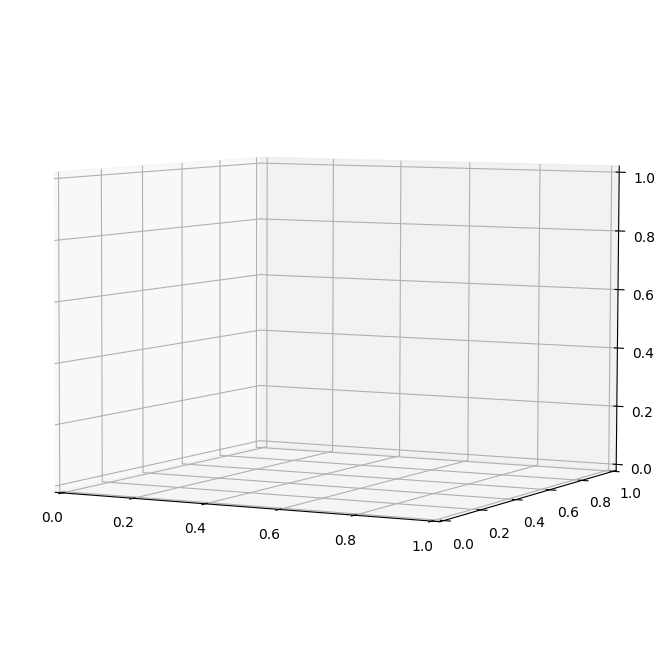

In [10]:
# %%
if __name__ == "__main__":
    app = QApplication.instance() or QApplication(sys.argv)
    main_win = ClassroomPredictorApp()
    main_win.show()
    app.exec()